# Листок № 2. Комплексные числа

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import gamma

## 2.1

In [2]:
i = sp.I
numbers = [
    (5+i)*(7-6*i)/(3+i),
    (1+i)**5/(1-i)**3,
    (-1+i*sp.sqrt(3))**15/(1-i)**20 + (-1-i*sp.sqrt(3))**15/(1+i)**20
]
for letter, number in zip('abc', numbers):
    number = sp.simplify(sp.expand_complex(number))
    r = sp.simplify(sp.Abs(number))
    angle = sp.simplify(sp.arg(number))
    print(letter, 'Алгебраическая:', number)
    print('Тригонометрическая:', r, '*(cos(', angle, ')+i*sin(', angle, '))')
    print('Показательная:', r, '*exp(i*(', angle, '))')

a Алгебраическая: 10 - 11*I
Тригонометрическая: sqrt(221) *(cos( -atan(11/10) )+i*sin( -atan(11/10) ))
Показательная: sqrt(221) *exp(i*( -atan(11/10) ))
b Алгебраическая: 2
Тригонометрическая: 2 *(cos( 0 )+i*sin( 0 ))
Показательная: 2 *exp(i*( 0 ))
c Алгебраическая: -64
Тригонометрическая: 64 *(cos( pi )+i*sin( pi ))
Показательная: 64 *exp(i*( pi ))


## 2.2

z 1 = (1.039245+0.102357j)
z 2 = (0.66248+0.807235j)
z 3 = (-0.102357+1.039245j)
z 4 = (-0.807235+0.66248j)
z 5 = (-1.039245-0.102357j)
z 6 = (-0.66248-0.807235j)
z 7 = (0.102357-1.039245j)
z 8 = (0.807235-0.66248j)


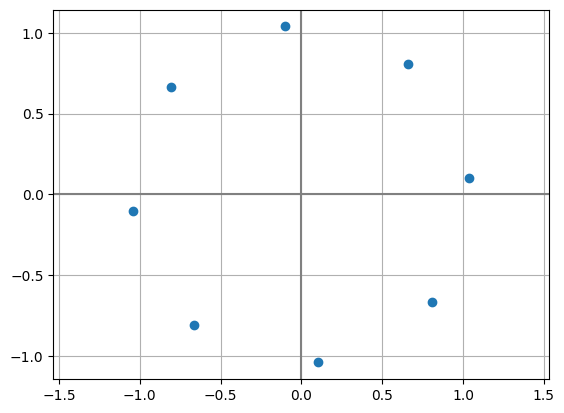

In [3]:
roots = []
for k in range(8):
    angle = (np.pi/4 + 2*np.pi*k)/8
    root = 2**(1/16) * np.exp(1j*angle)
    roots.append(root)
    print('z', k+1, '=', np.round(root, 6))
plt.scatter(np.real(roots), np.imag(roots))
plt.axhline(0, color='gray'); plt.axvline(0, color='gray')
plt.axis('equal'); plt.grid(); plt.show()

## 2.3

a 1 = (1+0j)
a 2 = (0.707107+0.707107j)
a 3 = 1j
a 4 = (-0.707107+0.707107j)
a 5 = (-1+0j)
a 6 = (-0.707107-0.707107j)
a 7 = (-0-1j)
a 8 = (0.707107-0.707107j)
b 1 = (1.5+0.866025j)
b 2 = (-0.866025+1.5j)
b 3 = (-1.5-0.866025j)
b 4 = (0.866025-1.5j)
c 1 = (2.039553-0.266679j)
c 2 = (-0.788826+1.899645j)
c 3 = (-1.250728-1.632965j)
d 1 = (1.035305-0.090577j)
d 2 = (0.851311+0.596095j)
d 3 = (0.26898+1.003847j)
d 4 = (-0.43921+0.941889j)
d 5 = (-0.941889+0.43921j)
d 6 = (-1.003847-0.26898j)
d 7 = (-0.596095-0.851311j)
d 8 = (0.090577-1.035305j)
d 9 = (0.734867-0.734867j)


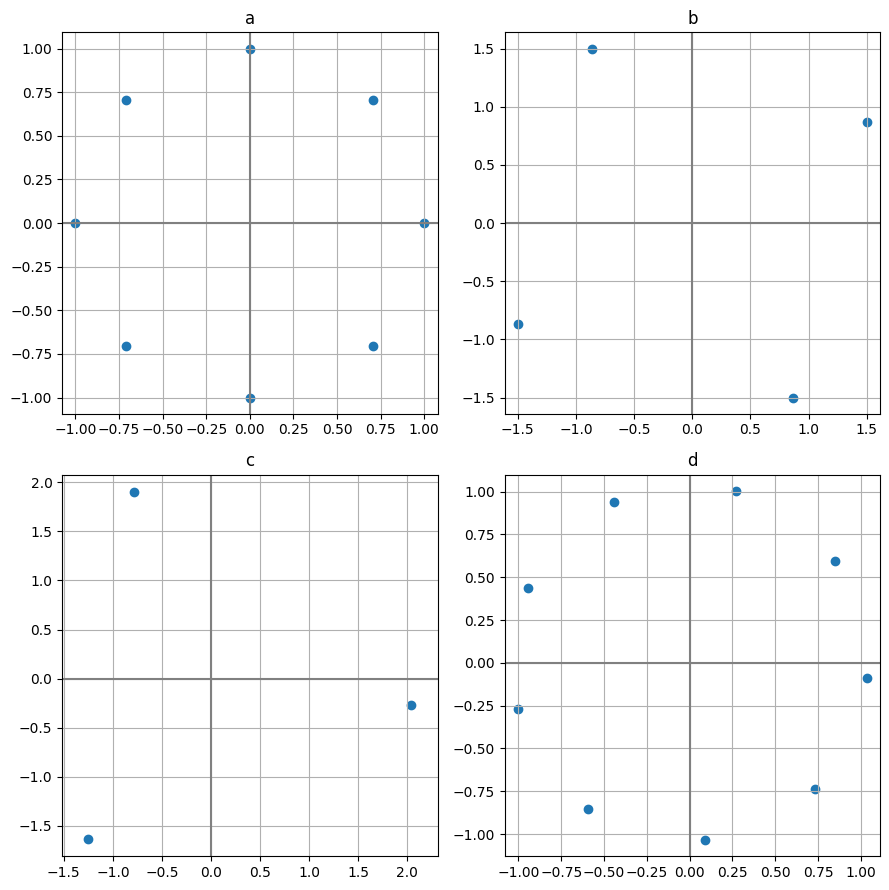

In [4]:
values = [
    1,
    -18/(1+1j*np.sqrt(3)),
    (1-5j)/(1+1j) - ((1+2j)/(2-1j))**(1/5) + 11,
    1-1j
]
degrees = [8, 4, 3, 9]
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for index in range(4):
    value = values[index]
    degree = degrees[index]
    roots = []
    for k in range(degree):
        angle = (np.angle(value)+2*np.pi*k)/degree
        root = abs(value)**(1/degree)*np.exp(1j*angle)
        roots.append(root)
        print('abcd'[index], k+1, '=', np.round(root, 6))
    ax = axes.flat[index]
    ax.scatter(np.real(roots), np.imag(roots))
    ax.axhline(0, color='gray'); ax.axvline(0, color='gray')
    ax.set_title('abcd'[index]); ax.axis('equal'); ax.grid()
plt.tight_layout(); plt.show()

## 2.4

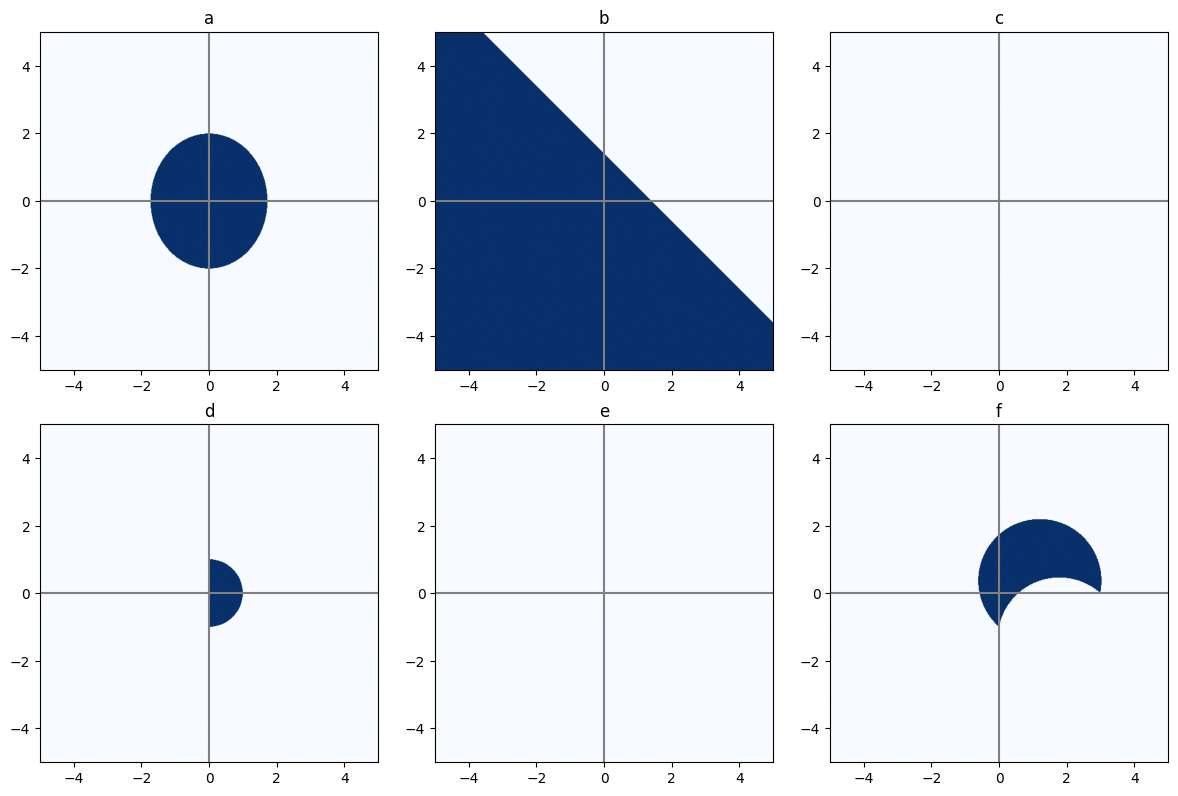

Ответ c: пустое множество
Ответ e: пустое множество (границы аргумента записаны в обратном порядке)


In [5]:
x = np.linspace(-5, 5, 550)
y = np.linspace(-5, 5, 550)
X, Y = np.meshgrid(x, y)
z = X + 1j*Y
with np.errstate(divide='ignore', invalid='ignore'):
    masks = [
        (abs(z-1j)+abs(z+1j)) < 4,
        np.real(z*(1-1j)) < np.sqrt(2),
        (abs(z+1) < 0.04) & (abs(z+1j) < 0.04) & (abs(z-1j) < 0.04),
        (np.angle((1j-z)/(z+1j)) > 0) & (np.angle((1j-z)/(z+1j)) < np.pi/2),
        (np.angle((2-1j*z)/(z+3j)) >= -2*np.pi/3) & (np.angle((2-1j*z)/(z+3j)) <= -5*np.pi/6),
        (np.angle((3-z)/(z+1j)) >= -2*np.pi/3) & (np.angle((3-z)/(z+1j)) <= -np.pi/3)
    ]
# Для пункта e верхняя граница -5π/6 меньше нижней -2π/3: решений нет.
# В пункте c равенства одновременно невозможны.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for index in range(6):
    ax = axes.flat[index]
    ax.imshow(masks[index], extent=[-5, 5, -5, 5], origin='lower', cmap='Blues', vmin=0, vmax=1)
    ax.axhline(0, color='gray'); ax.axvline(0, color='gray')
    ax.set_title('abcdef'[index]); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print('Ответ c: пустое множество')
print('Ответ e: пустое множество (границы аргумента записаны в обратном порядке)')

## 2.5

In [6]:
A, C = sp.symbols('A C', real=True, positive=True)
b1, b2 = sp.symbols('b1 b2', real=True)
B = b1 + sp.I*b2
center = -B/A
radius = sp.sqrt(b1**2+b2**2-A*C)/A
print('Центр:', center)
print('Радиус:', radius)

Центр: (-b1 - I*b2)/A
Радиус: sqrt(-A*C + b1**2 + b2**2)/A


## 2.6

In [7]:
x = sp.symbols('x')
p = x**11+x**10+x**8-2*x**7-x**5+x**4+2*x**2+2*x+2
roots = sp.nroots(p, maxsteps=300)
for root in roots:
    print(complex(root))
print('Ответ 1:', round(sum(abs(complex(root)) for root in roots), 6))
print('Ответ 2:', round(max(complex(root).real for root in roots), 6))

(-1.7767690249210157+0j)
(-0.7074344552119215-0.4643747258648715j)
(-0.7074344552119215+0.4643747258648715j)
(-0.45003711274344693-0.8039231442480758j)
(-0.45003711274344693+0.8039231442480758j)
(-0.012500180564548801-1.1826990817461014j)
(-0.012500180564548801+1.1826990817461014j)
(0.4777545236225798-0.9010752305378562j)
(0.4777545236225798+0.9010752305378562j)
(1.0806017373578454-0.3238931188400023j)
(1.0806017373578454+0.3238931188400023j)
Ответ 1: 11.973384
Ответ 2: 1.080602


## 2.7

a) (4.367449140640134+4.851629765157813j)
б) 0.8378693695500427 радиан; 48.00637865850454 градусов


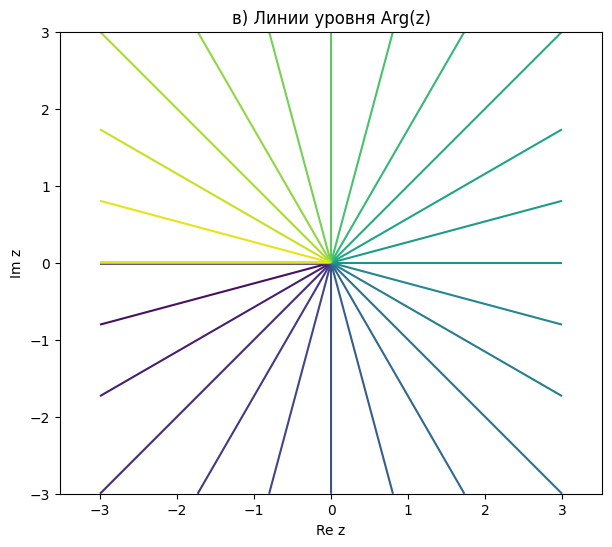

In [8]:
from scipy.special import loggamma
z = 1+1j
w = 1-1j
value = np.exp(loggamma(z+1)-loggamma(w+1)-loggamma(z-w+1))
print('a)', value)
print('б)', np.angle(value), 'радиан;', np.degrees(np.angle(value)), 'градусов')
x = np.linspace(-3, 3, 350)
y = np.linspace(-3, 3, 350)
X, Y = np.meshgrid(x, y)
Z = X+1j*Y
with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    coefficient = Z
    angles = np.angle(coefficient)
plt.figure(figsize=(7, 6))
plt.contour(X, Y, angles, levels=np.linspace(-np.pi, np.pi, 25))
plt.title('в) Линии уровня Arg(z)')
plt.xlabel('Re z'); plt.ylabel('Im z'); plt.axis('equal'); plt.show()

## 2.8

In [9]:
lam = np.exp(2j*np.pi/14)
A = np.array([[7, 5], [6, 2]])
value = np.linalg.det(A+lam*np.eye(2))
print('Ответ 1:', round(value.real, 6))
print('Ответ 2:', round(value.imag, 6))

Ответ 1: -7.26779
Ответ 2: 4.686785


## 2.9

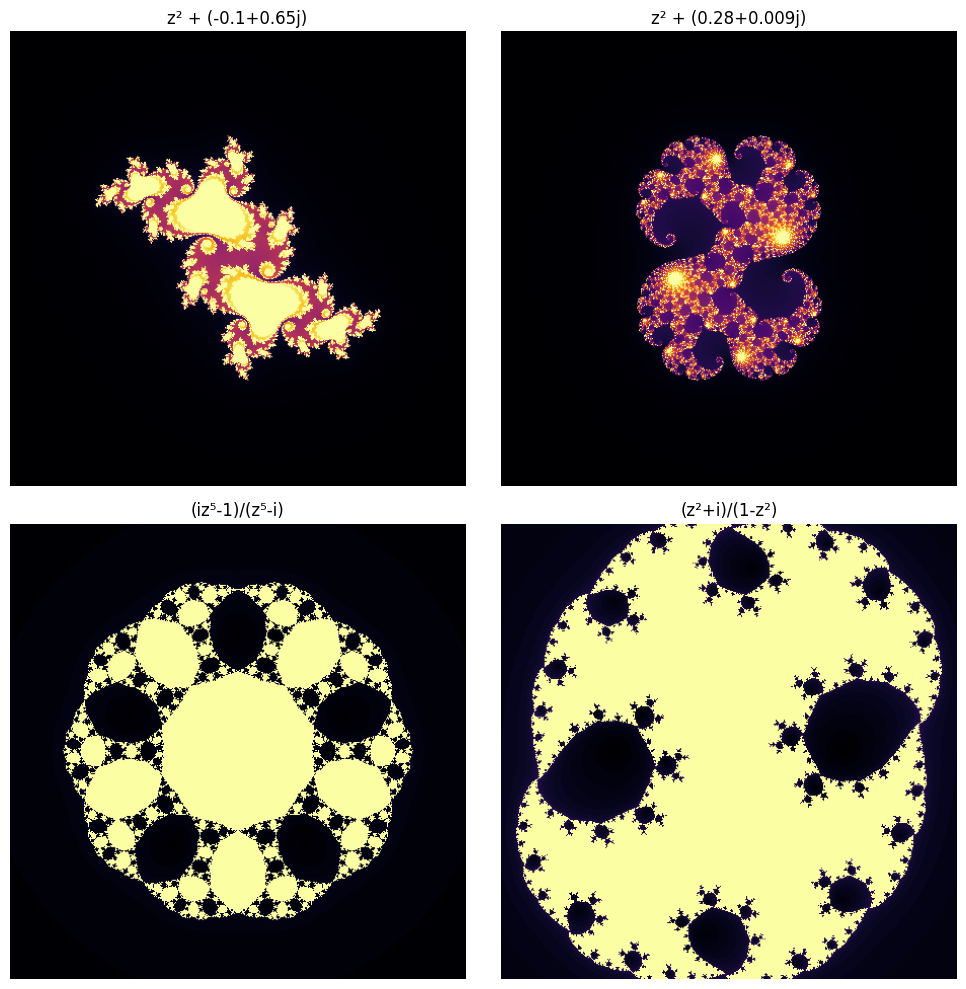

Ответ: четыре изображения построены


In [10]:
x = np.linspace(-2, 2, 450)
y = np.linspace(-2, 2, 450)
X, Y = np.meshgrid(x, y)
start = X+1j*Y

def julia(c, kind):
    z = start.copy()
    steps = np.zeros(z.shape, dtype=int)
    active = np.ones(z.shape, dtype=bool)
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        for k in range(170):
            if kind == 1:
                new = z*z+c
            elif kind == 2:
                new = (1j*z**5-1)/(z**5-1j)
            else:
                new = (z*z+1j)/(1-z*z)
            active = active & np.isfinite(new) & (abs(new) < 10)
            steps[active] = k+1
            z[active] = new[active]
            z[~active] = 20
    return steps

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
examples = [(-0.1+0.65j, 1), (0.28+0.009j, 1), (0, 2), (0, 3)]
for ax, (c, kind) in zip(axes.flat, examples):
    image = julia(c, kind)
    ax.imshow(image, extent=[-2, 2, -2, 2], origin='lower', cmap='inferno')
    ax.set_title(['', 'z² + '+str(c), '(iz⁵-1)/(z⁵-i)', '(z²+i)/(1-z²)'][kind])
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Ответ: четыре изображения построены')

## 2.10 (кривые)

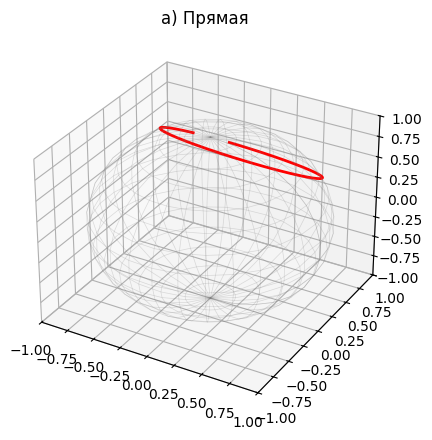

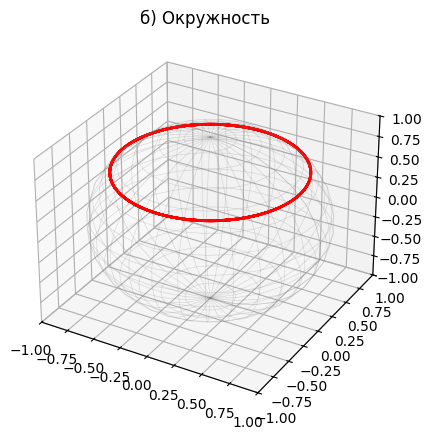

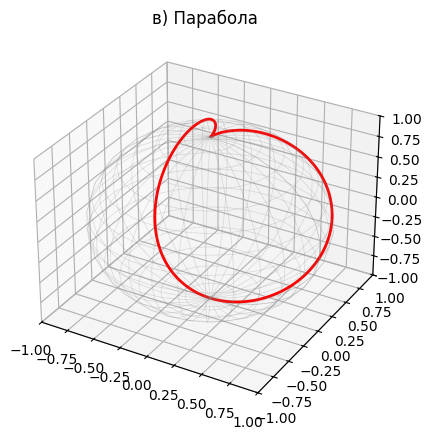

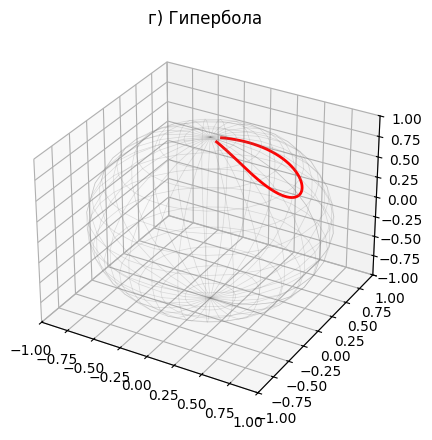

Ответ: четыре кривые изображены


In [11]:
from mpl_toolkits.mplot3d import Axes3D

def show_on_sphere(x, y, title):
    denominator = x*x+y*y+1
    X = 2*x/denominator
    Y = 2*y/denominator
    Z = (x*x+y*y-1)/denominator
    u = np.linspace(0, 2*np.pi, 30)
    v = np.linspace(0, np.pi, 16)
    sx = np.outer(np.cos(u), np.sin(v))
    sy = np.outer(np.sin(u), np.sin(v))
    sz = np.outer(np.ones(len(u)), np.cos(v))
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_wireframe(sx, sy, sz, color='gray', alpha=0.25, linewidth=0.5)
    ax.plot(X, Y, Z, color='red', linewidth=2)
    ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1), title=title)
    plt.show()

t = np.linspace(-12, 12, 1500)
show_on_sphere(t, t*0+1, 'а) Прямая')
show_on_sphere(2*np.cos(t), 2*np.sin(t), 'б) Окружность')
show_on_sphere(t, t*t, 'в) Парабола')
show_on_sphere(2*np.cosh(np.linspace(-3, 3, 1500)), np.sinh(np.linspace(-3, 3, 1500)), 'г) Гипербола')
print('Ответ: четыре кривые изображены')

## 2.10 (логарифмическая спираль)

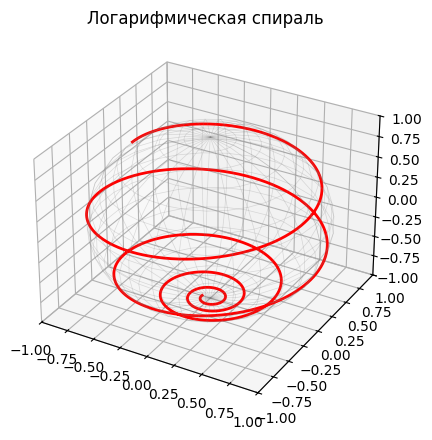

Ответ: спираль изображена


In [12]:
angle = np.linspace(-5*np.pi, 5*np.pi, 2500)
a = 0.3
b = 0.13
radius = a*np.exp(b*angle)
x = radius*np.cos(angle)
y = radius*np.sin(angle)
show_on_sphere(x, y, 'Логарифмическая спираль')
print('Ответ: спираль изображена')